In [1]:
from Dataset import MatrixGenerator

In [2]:
MG = MatrixGenerator()
rm, random_matrix, missing_mask, L_r, L_c = MG.get_matrix(m=1000, n=800, k=12, random_state=70, missing_fraction=0.95, 
                                                          noise_level=0, with_graphs=True)

n_communities: 15


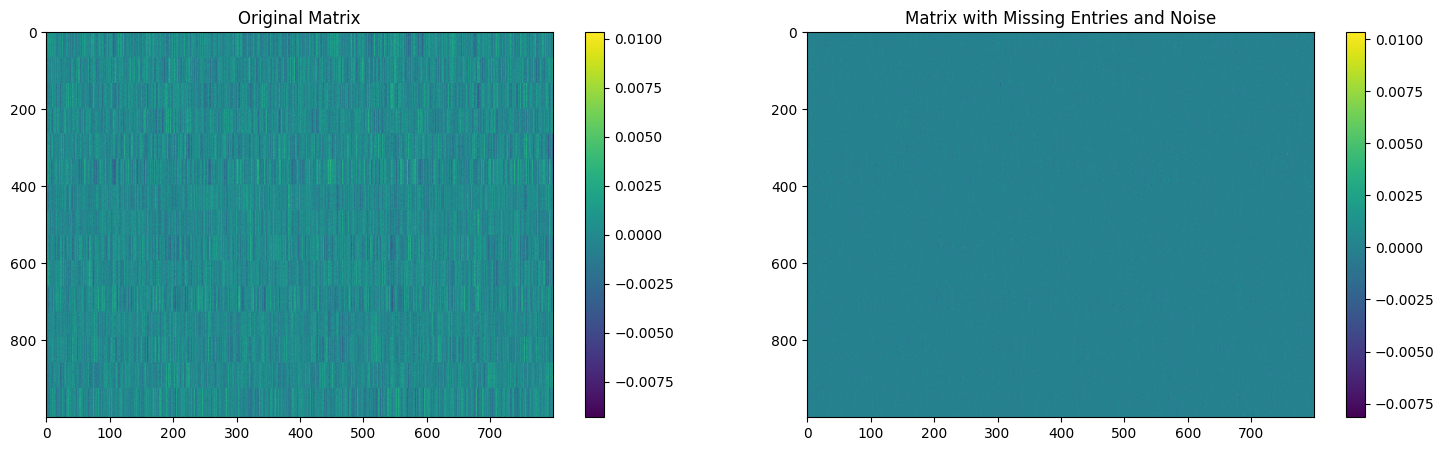

In [3]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(18, 5))
plt.subplot(1, 2, 1)
plt.title("Original Matrix")
plt.imshow(random_matrix, aspect="auto", cmap="viridis")
plt.colorbar()
plt.subplot(1, 2, 2)
plt.title("Matrix with Missing Entries and Noise")
plt.imshow(random_matrix * missing_mask, aspect="auto", cmap="viridis")
plt.colorbar()

In [4]:
import numpy as np
from algorithms.RCGMatrixCompletion import RCGMatrixCompletion

import json
params_reg = json.dumps({
    "m": 1000,                 # Number of rows
    "n": 800,                 # Number of columns
    "rank": 12,              # Rank of the original matrix
    "missing_fraction": 0.95, # 50% of the entries will be missing
    "noise_level": 0,        # Standard deviation of Gaussian noise
    "num_iters": 50,        # Maximum number of iterations for completion
    "tol": 1e-9,             # Convergence tolerance, np.inf if it not need
    "alpha": 1e-4,           # Another custom parametrs,
    "delta": 1e-7,
    "gamma_c": 0,
    "gamma_r": 1e-1
})

params_noreg = json.dumps({
    "m": 1000,                 # Number of rows
    "n": 8000,                 # Number of columns
    "rank": 12,              # Rank of the original matrix
    "missing_fraction": 0.9, # 50% of the entries will be missing
    "noise_level": 0,        # Standard deviation of Gaussian noise
    "num_iters": 50,        # Maximum number of iterations for completion
    "tol": 1e-9,             # Convergence tolerance, np.inf if it not need
    "alpha": 0,           # Another custom parametrs,
    "delta": 1e-5,
    "gamma_c": 0,
    "gamma_r": 0
})

MC_reg = RCGMatrixCompletion(params_str=params_reg, L_c=L_c, L_r=L_r)
factorization_reg = MC_reg.complete_matrix(random_matrix, missing_mask, metric="QPRECON", method = "rcd", delta=1e-10)

MC_noreg = RCGMatrixCompletion(params_str=params_noreg, L_c=L_c, L_r=L_r)
factorization_noreg = MC_noreg.complete_matrix(random_matrix, missing_mask, metric="QPRECON", method = "rcd", delta=1e-10)

MC_reg_gd = RCGMatrixCompletion(params_str=params_reg, L_c=L_c, L_r=L_r)
factorization_reg = MC_reg_gd.complete_matrix(random_matrix, missing_mask, metric="QPRECON", method = "rgd", delta=1e-10)

MC_noreg_gd = RCGMatrixCompletion(params_str=params_noreg, L_c=L_c, L_r=L_r)
factorization_noreg = MC_noreg_gd.complete_matrix(random_matrix, missing_mask, metric="QPRECON", method = "rgd", delta=1e-10)

theta_r shape: (1000, 1000)
theta_c shape: (800, 800)
U size: (1000, 800)
S size: (800,)
Vt size: (800, 800)
M size: (1000, 800)
Omega size: (1000, 800)


100%|██████████| 50/50 [00:07<00:00,  6.29it/s]


theta_r shape: (1000, 1000)
theta_c shape: (800, 800)
U size: (1000, 800)
S size: (800,)
Vt size: (800, 800)
M size: (1000, 800)
Omega size: (1000, 800)


100%|██████████| 50/50 [00:07<00:00,  6.42it/s]


theta_r shape: (1000, 1000)
theta_c shape: (800, 800)
U size: (1000, 800)
S size: (800,)
Vt size: (800, 800)
M size: (1000, 800)
Omega size: (1000, 800)


100%|██████████| 50/50 [00:07<00:00,  7.08it/s]


theta_r shape: (1000, 1000)
theta_c shape: (800, 800)
U size: (1000, 800)
S size: (800,)
Vt size: (800, 800)
M size: (1000, 800)
Omega size: (1000, 800)


100%|██████████| 50/50 [00:06<00:00,  7.18it/s]


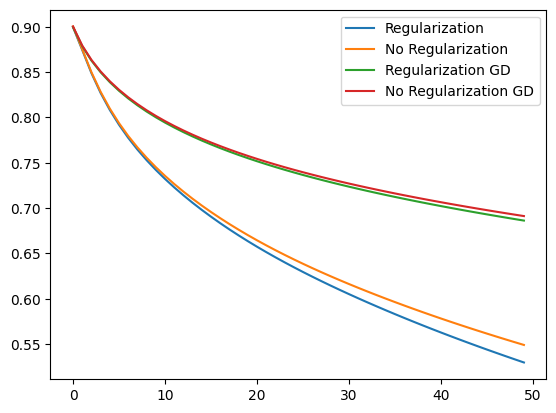

In [5]:
import matplotlib.pyplot as plt

# Assuming costs_reg, costs_noreg, costs_reg_gd, and costs_noreg_gd are defined
costs_reg = [info['relative_error'] for info in MC_reg.iters_info]
costs_noreg = [info['relative_error'] for info in MC_noreg.iters_info]
costs_reg_gd = [info['relative_error'] for info in MC_reg_gd.iters_info]
costs_noreg_gd = [info['relative_error'] for info in MC_noreg_gd.iters_info]

# Plotting the data with labels
plt.plot(costs_reg, label='Regularization')
plt.plot(costs_noreg, label='No Regularization')
plt.plot(costs_reg_gd, label='Regularization GD')
plt.plot(costs_noreg_gd, label='No Regularization GD')

# Adding the legend
plt.legend()

# Show the plot
plt.show()


In [6]:
params_reg = json.loads(params_reg)
experiments = [{"iters_info" : MC_reg.iters_info,
                "alpha": params_reg["alpha"], 
                "OS": params_reg["missing_fraction"],
                "rank": params_reg["rank"]}]

49


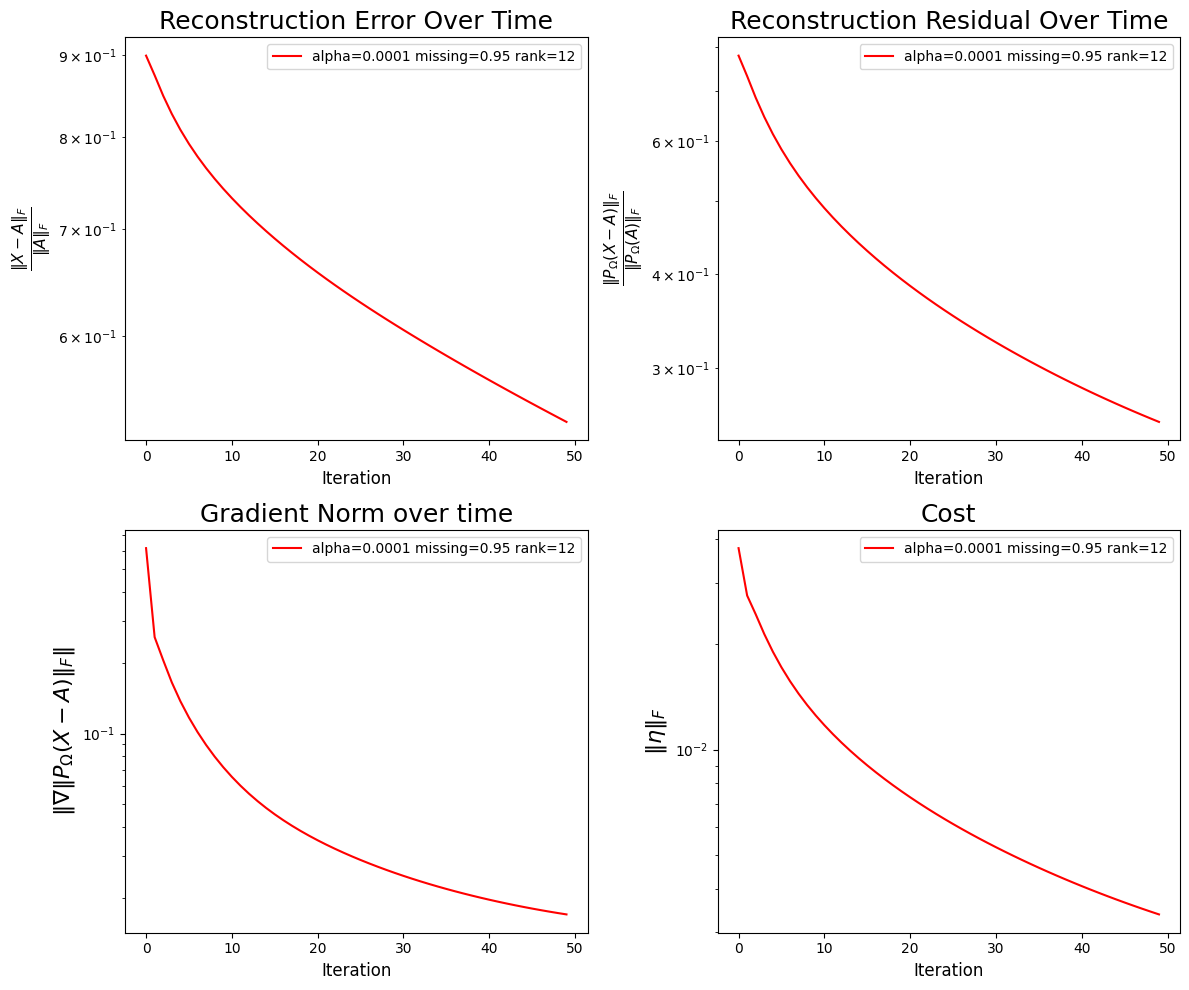

In [7]:
MC_reg.plot_info(experiments)